In [1]:
%load_ext autoreload
%autoreload 2

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from scipy.interpolate import interp1d
import pandas as pd
import sncosmo
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
from joblib import Parallel, delayed
import cloudpickle as pickle
from regions import RectangleSkyRegion
from astropy.coordinates import SkyCoord
import astropy.units as u

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightcurvelynx.obstable.ztf_obstable import ZTFObsTable, _ztfcam_ccd_gain
from lightcurvelynx.astro_utils.mag_flux import mag2flux
import sqlite3

from lightcurvelynx.obstable.ztf_obstable import ZTFObsTable
from lightcurvelynx.obstable.fake_obs_table import FakeObsTable
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.pzflow_node import PZFlowNode
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.models.sncomso_models import SncosmoWrapperModel
from lightcurvelynx.models.snia_host import SNIaHost
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.astro_utils.mag_flux import mag2flux,flux2mag
from lightcurvelynx.astro_utils.detector_footprint import DetectorFootprint

from lightcurvelynx.graph_state import GraphState
from lightcurvelynx.simulate import compute_single_noise_free_lightcurve
from lightcurvelynx.astro_utils.noise_model import poisson_bandflux_std

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR

from lightcurvelynx.validation.lcfit import fit_single_lc

from utils.plotting_utils import convert_flux_to_njy, plot_coverage_map

In [3]:
globalhostdata = pd.read_csv('ztfsniadr2/tables/globalhost_data.csv')
localhostdata = pd.read_csv('ztfsniadr2/tables/localhost_data.csv')
sndata = pd.read_csv('ztfsniadr2/tables/snia_data.csv')
data = pd.merge(sndata,globalhostdata,on='ztfname')

In [4]:
lcdata = read_parquet('data/ztfsniadr2.parquet')

In [5]:
list2 = pd.read_csv('/Users/mi/Downloads/ztfnames',header=None)[0].to_list()

In [6]:
list1 = data.iau_name.to_list()

In [7]:
# randomly pick an SN in the data release to simulate
# ZTF20abegoix - this one looks good for paper
# ZTF19aazlsfj - also good
# random_sn = data.dropna().sample()
random_sn = data.loc[data.iau_name == "2020jny"]
random_sn

,Unnamed: 0,ztfname,redshift,redshift_err,source,t0,x0,x1,c,t0_err,...,fitquality_flag,iau_name,frac_fitted,ra_host,dec_host,mass,mass_err,restframe_gz,restframe_gz_err,d_dlr
2690,2690,ZTF20aazgtmp,0.023708,0.000021,z_gal,58993.144828,0.005328,-1.524705,-0.056194,0.159406,...,1.0,2020jny,100.0,180.743888,20.085211,9.213,0.114612,1.066697,0.019849,0.310123


In [8]:
random_lc = lcdata.loc[lcdata["ztfname"] == random_sn.ztfname.values[0]]
random_lc['lc'].iloc[0]

,mjd,filter,flux,flux_err,ZP,flag,mag,mag_err,field_id,rcid,flux_offset,offset_unc,err_scale,in_baseline
0,58131.45685,ztfg,938.89350,1248.08315,30.0,64,99.0,99.0,575,37.0,-171.27878,152.90124,1.00000,1
1,58131.46291,ztfg,-701.20079,1136.62071,30.0,64,99.0,99.0,575,37.0,-171.27878,152.90124,1.00000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,59798.16117,ztfr,-8168.96201,3532.85301,30.0,392,99.0,99.0,575,37.0,-567.64475,174.40047,1.24398,0
842,59798.16354,ztfr,8585.96939,3438.76922,30.0,392,99.0,99.0,575,37.0,-567.64475,174.40047,1.24398,0


In [9]:
obs_log = pd.read_parquet('data/ztf_observing_log_combined_w_metadata.parquet')
colmap = {"ra":"ra",
          "dec":"dec",
          "time":"mjd",
          "zp":"zp_nJy",
          "filter":"filter",
          "sky":"scibckgnd",
         }

#ztf ccd size 6144 × 6160 pixel * 16
pixel_scale = 1.01 #arcsec/pixel
center = SkyCoord(ra=0.0, dec=0.0, unit="deg", frame="icrs")
rect_region = RectangleSkyRegion(center=center, width=4*6144.* pixel_scale * u.arcsec, 
                                 height=4*6160.* pixel_scale * u.arcsec, angle=0.0 * u.deg)
ztf_fp = DetectorFootprint(rect_region, pixel_scale=pixel_scale)

ztf_obstable = ZTFObsTable(obs_log,colmap=colmap,detector_footprint=ztf_fp)

In [10]:
ra, dec = random_sn.ra.values[0], random_sn.dec.values[0]
idx = ztf_obstable.range_search(ra,dec)
table = ztf_obstable._table.iloc[idx]
table

,time,band,fieldid,fieldra,fielddec,rcid,maglimit,zp_abmag,gain,expid,...,skynoise,filter,exptime,fwhm,obsdate,sky,ra,dec,zp,obsmjd
1297,58290.191406,ztfg,575,3.147249,0.33074,18,20.322866,26.151114,6.2,53619111,...,42.347675,g,30.0,2.488525,2018-06-21 04:35:12.755,82.5505,180.324083,18.95,20.284435,58290.191120
1422,58290.253906,ztfr,575,3.147249,0.33074,17,20.266237,26.110249,6.2,53625289,...,42.996243,r,30.0,2.214460,2018-06-21 06:04:10.120,219.2490,180.324083,18.95,21.062450,58290.252895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518639,59269.398438,ztfi,575,3.147249,0.33074,0,20.666645,25.660049,6.1,151540010,...,16.851154,i,30.0,1.647275,2021-02-24 09:36:09.905,247.3870,180.324083,18.95,31.885155,59269.400115
519400,59270.339844,ztfr,575,3.147249,0.33074,22,20.432985,26.292171,6.3,151634013,...,48.109451,r,30.0,2.026150,2021-02-25 08:09:48.172,258.9085,180.324083,18.95,17.813109,59270.340141


In [11]:
obs_log_allccd = pd.read_parquet('ztfsniadr2/tables/observing_logs.parquet')
obs_log_allccd = obs_log_allccd[obs_log_allccd["expid"].isin(table.expid)]
obs_log_allccd

,mjd,band,fieldid,fieldra,fielddec,rcid,maglimit,zp,gain,expid,infobits,skynoise
82277,58290.191406,ztfg,575,3.147249,0.33074,18,20.322866,26.137365,6.2,53619111,0,42.347675
82278,58290.191406,ztfg,575,3.147249,0.33074,19,20.367065,26.122066,6.2,53619111,0,40.089481
...,...,...,...,...,...,...,...,...,...,...,...,...
32632768,59270.339844,ztfr,575,3.147249,0.33074,47,20.396891,26.348890,6.3,151634013,0,48.065102
32632769,59270.339844,ztfr,575,3.147249,0.33074,42,20.437506,26.418007,6.1,151634013,0,49.343559


In [12]:
df1 = table
df2 = random_lc['lc'].iloc[0]
df3 = obs_log_allccd

In [13]:
# match the rcid for that sn
dflist = []
for i,row in df2.drop_duplicates(['field_id','rcid']).iterrows():
    df = df3.loc[(df3.fieldid == row['field_id']) & (df3.rcid == row['rcid'])]
    dflist.append(df)
obs_log = pd.concat(dflist)
obs_log

,mjd,band,fieldid,fieldra,fielddec,rcid,maglimit,zp,gain,expid,infobits,skynoise
82330,58290.191406,ztfg,575,3.147249,0.330740,37,20.411980,26.116980,6.2,53619111,0,38.285114
90322,58290.253906,ztfr,575,3.147249,0.330740,37,20.334553,26.107553,6.2,53625289,0,40.759636
...,...,...,...,...,...,...,...,...,...,...,...,...
32045589,59256.355469,ztfr,1620,3.100007,0.393572,0,21.502792,26.164793,6.1,150235403,0,14.649752
32572083,59269.292969,ztfr,1620,3.100007,0.393572,0,20.760176,26.167175,6.1,151529188,0,29.095768


In [14]:
con = sqlite3.connect("data/ztf_metadata_latest.db")
sql_query = "SELECT * FROM exposures"
metadata_table = pd.read_sql_query(sql_query, con)
metadata_table = metadata_table.replace("", np.nan)
metadata_table = metadata_table.dropna(subset=["fwhm"])
metadata_table.columns

/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_56207/2534340399.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata_table = metadata_table.replace("", np.nan)


Index(['expid', 'field', 'filter', 'obsdate', 'ra', 'dec', 'exptime',
       'airmass', 'infobits', 'dr', 'numsci', 'numdiff', 'fwhm', 'maglim',
       'scibckgnd', 'ellip', 'ellippa'],
      dtype='object')

In [15]:
obs_log["filter"] = obs_log.apply(lambda row: row["band"][-1],axis=1)
obs_log = pd.merge(obs_log, metadata_table[["expid","filter","exptime","fwhm","obsdate","scibckgnd","ra","dec"]],on=["filter","expid"])
gain = _ztfcam_ccd_gain
obs_log["zp_nJy"] = mag2flux(obs_log["zp"].values + 2.5*np.log10(gain))
obs_log = obs_log.rename(columns={"zp":"zp_abmag"})
obs_log

,mjd,band,fieldid,fieldra,fielddec,rcid,maglimit,zp_abmag,gain,expid,infobits,skynoise,filter,exptime,fwhm,obsdate,scibckgnd,ra,dec,zp_nJy
0,58290.191406,ztfg,575,3.147249,0.330740,37,20.411980,26.116980,6.2,53619111,0,38.285114,g,30.0,2.488525,2018-06-21 04:35:12.755,82.5505,180.324083,18.95,20.932277
1,58290.253906,ztfr,575,3.147249,0.330740,37,20.334553,26.107553,6.2,53625289,0,40.759636,r,30.0,2.214460,2018-06-21 06:04:10.120,219.2490,180.324083,18.95,21.114797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,59256.355469,ztfr,1620,3.100007,0.393572,0,21.502792,26.164793,6.1,150235403,0,14.649752,r,30.0,1.908720,2021-02-11 08:29:49.529,417.3925,177.617292,22.55,20.030468
689,59269.292969,ztfr,1620,3.100007,0.393572,0,20.760176,26.167175,6.1,151529188,0,29.095768,r,30.0,1.706595,2021-02-24 07:00:19.753,414.6525,177.617292,22.55,19.986567


In [16]:
colmap = {"ra":"ra",
          "dec":"dec",
          "time":"mjd",
          "zp":"zp_nJy",
          "filter":"filter",
          "sky":"scibckgnd",
         }

#ztf ccd size 6144 × 6160 pixel * 16
pixel_scale = 1.01 #arcsec/pixel
center = SkyCoord(ra=0.0, dec=0.0, unit="deg", frame="icrs")
rect_region = RectangleSkyRegion(center=center, width=4*6144.* pixel_scale * u.arcsec, 
                                 height=4*6160.* pixel_scale * u.arcsec, angle=0.0 * u.deg)
ztf_fp = DetectorFootprint(rect_region, pixel_scale=pixel_scale)

ztf_obstable = ZTFObsTable(obs_log,colmap=colmap,detector_footprint=ztf_fp)
ztf_obstable.survey_values["zp_err_mag"] = 0.001

t_min, t_max = ztf_obstable.time_bounds()
print(f"Loaded OpSim with {len(ztf_obstable)} rows and times [{t_min}, {t_max}]")

passband_group = PassbandGroup.from_preset(preset="ZTF", filters=["g", "r", "i"])
print(f"Loaded Passbands: {passband_group}")

Loaded OpSim with 690 rows and times [58290.19140625, 59270.33984375]
Loaded Passbands: PassbandGroup containing 3 passbands: ZTF_g, ZTF_r, ZTF_i


In [17]:
H0 = 70.0
Omega_m = 0.3

host = SNIaHost(
    ra = random_sn.ra_host,
    dec = random_sn.dec,
    hostmass= random_sn.mass,
    redshift=random_sn.redshift,
    node_label="host",
)

In [18]:
sncosmo_modelname = "salt3"
source = SncosmoWrapperModel(
    sncosmo_modelname,
    t0=random_sn.t0.values[0],
    x0=random_sn.x0.values[0],
    x1=random_sn.x1.values[0],
    c=random_sn.c.values[0],
    ra=random_sn.ra.values[0],
    dec=random_sn.dec.values[0],
    redshift=random_sn.redshift.values[0],
    node_label="source",
)
    
mwextinction = SFDMap(
    ra=source.ra,
    dec=source.dec,
    node_label="mwext",
)

# Create an extinction effect using the EBVs from that dust map.
ext_effect = ExtinctionEffect(extinction_model="F99", frame='observer', ebv=mwextinction, Rv=3.1)
source.add_effect(ext_effect)


In [19]:
nsntotal = 100
lightcurves = simulate_lightcurves(source, int(nsntotal), ztf_obstable, passband_group, 
                                   obstable_save_cols=["expid","zp_nJy","scibckgnd","skynoise","fwhm","maglimit"])
lightcurves

id          ra        dec  nobs            t0         z  \
0    0  180.743751  20.085418   690  58993.144828  0.023708   
1    1  180.743751  20.085418   690  58993.144828  0.023708   
..  ..         ...        ...   ...           ...       ...   
98  98  180.743751  20.085418   690  58993.144828  0.023708   
99  99  180.743751  20.085418   690  58993.144828  0.023708   

                                               params  \
0   {'source.ra': 180.743751, 'source.dec': 20.085...   
1   {'source.ra': 180.743751, 'source.dec': 20.085...   
..                                                ...   
98  {'source.ra': 180.743751, 'source.dec': 20.085...   
99  {'source.ra': 180.743751, 'source.dec': 20.085...   

                                           lightcurve  
0   [{mjd: 58290.191406, filter: 'g', flux: 1883.0...  
1   [{mjd: 58290.191406, filter: 'g', flux: -3650....  
..                                                ...  
98  [{mjd: 58290.191406, filter: 'g', flux: -3941....  
99  [{mjd: 58290.191406, filter: 'g', flux: 1533.1...  

[100 rows x 8 columns]

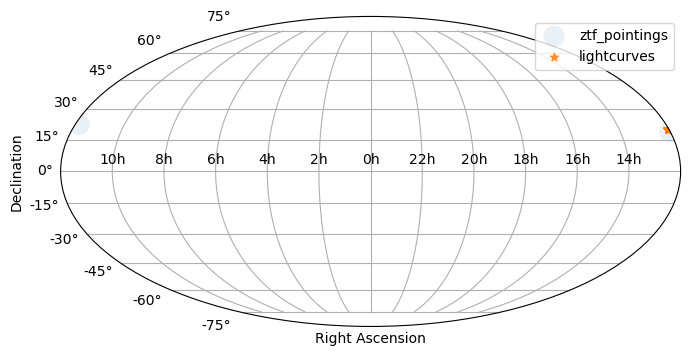

In [20]:
plot_coverage_map(ztf_obstable,lightcurves,plot_na_location=False,plot_all_location=True)

In [21]:
lightcurves = lightcurves.rename(columns={"lightcurve":"lc"})
lightcurves = lightcurves.dropna(subset="lc")

In [22]:
lightcurves['lc.snr'] = lightcurves['lc.flux']/lightcurves['lc.fluxerr']
detection_snr_thres = 5.
lightcurves['lc.detection_flag'] = lightcurves['lc.snr'] > detection_snr_thres
# drop saturation
lightcurves_after_drop_sat = lightcurves.query("lc.is_saturated==False").dropna()
# drop non detection
lightcurves_after_detection = lightcurves_after_drop_sat.query("lc.detection_flag == True").dropna()

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


In [23]:
def filter_flags(lc_flag, flags_to_exclude=[], flags_to_include=[]):
    pass_filter = True
    if len(flags_to_include)>0:
        pass_filter &= np.all([lc_flag & flag != 0 for flag in flags_to_include])
    if len(flags_to_exclude)>0:
        pass_filter &= np.all([lc_flag & flag == 0 for flag in flags_to_exclude])
    return pass_filter

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:321: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(nested, new_nested_series)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/utils/plotting.py:112: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.

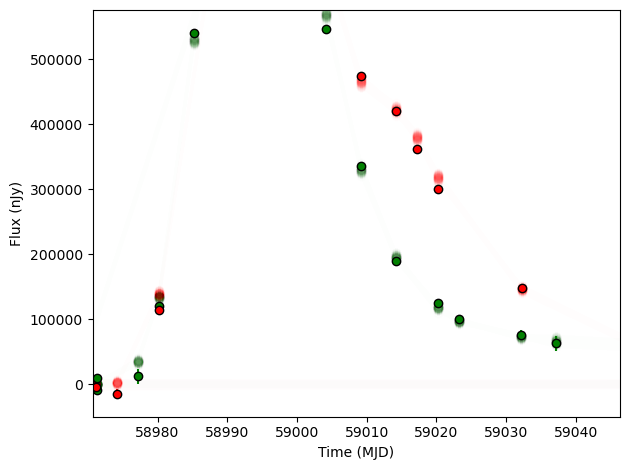

In [24]:
sncosmo_modelname = "salt3"
random_ids = lightcurves.id.sample(1).values
colormap = {'g':'g',
            'r':'r',
            'i':'purple',}

ax = plt.subplot()
        
# lc_all = lightcurves_after_detection
lc_all = lightcurves.dropna(subset=["lc"])

ax = plot_lightcurves(
    fluxes=lc_all["lc.flux"],
    times=lc_all["lc.mjd"],
    filters=lc_all["lc.filter"],
    colormap=colormap,
    underlying_model=None,#noise_free_lcs,
    alpha = 0.007,
    ax = ax,
)


plt.ylabel('Flux (nJy)')

lc_plot = random_lc
lc_plot["lc.pass_flag_filter"] = lc_plot["lc.flag"].apply(filter_flags,flags_to_exclude=[1,2,4,8,16,32],flags_to_include=[])
lc_plot = lc_plot.query("lc.pass_flag_filter == True")

#plot the data
lc_plot["lc.flux"], lc_plot["lc.flux_err"] = convert_flux_to_njy(lc_plot["lc.flux"],lc_plot["lc.flux_err"],zp=30.)

plot_lightcurves(
    fluxes=lc_plot["lc.flux"],
    times=lc_plot["lc.mjd"],
    fluxerrs=lc_plot["lc.flux_err"],
    filters=[x[-1] for x in lc_plot["lc.filter"]],
    colormap=colormap,
    ax = ax,
    marker = "o",
    markeredgecolor = "k",
)

t_min, t_max = -2 + random_sn.t0.values[0] - 20*(1+random_sn.redshift.values[0]), 2 + random_sn.t0.values[0] + 50*(1+random_sn.redshift.values[0])
plt.xlim((t_min,t_max))
plt.gca().get_legend().remove()
plt.ylim((-5e4,mag2flux(17)))
plt.tight_layout()

plt.savefig("paper_figs/example_lc.png")

In [25]:
lynx_lc = lc_all.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]
ztf_lc = lc_plot.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


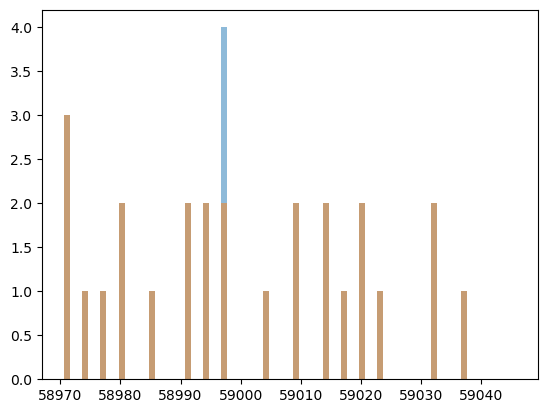

In [26]:
bins = np.arange(t_min,t_max,1)
plt.hist(lynx_lc.mjd,bins=bins,alpha=0.5)
plt.hist(ztf_lc.mjd,bins=bins,alpha=0.5)
plt.show()

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: 

Text(0, 0.5, 'flux_sim/flux_data')

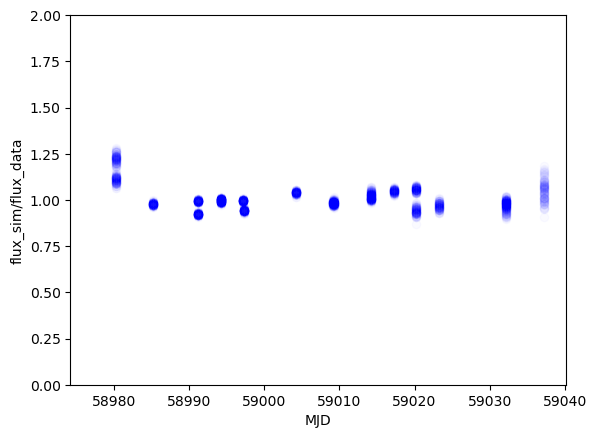

In [27]:
ztf_lc = lc_plot.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]

for i in range(0,len(lightcurves)):
    lynx_lc = lc_all.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[i]
    
    merged = pd.merge_asof(
        lynx_lc.sort_values('mjd'),
        ztf_lc.sort_values('mjd'),
        on='mjd',
        direction='nearest',
        tolerance=0.01,
        suffixes = ('_lynx','_ztf'),
    )
    merged = merged.dropna().loc[merged.dropna().detection_flag]
    plt.plot(merged.mjd,merged.flux_lynx/merged.flux_ztf,'o',alpha=0.02,color='b')
plt.ylim((0,2))
plt.xlabel('MJD')
plt.ylabel("flux_sim/flux_data")

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: 

Text(0, 0.5, 'fluxerr_sim/fluxerr_data')

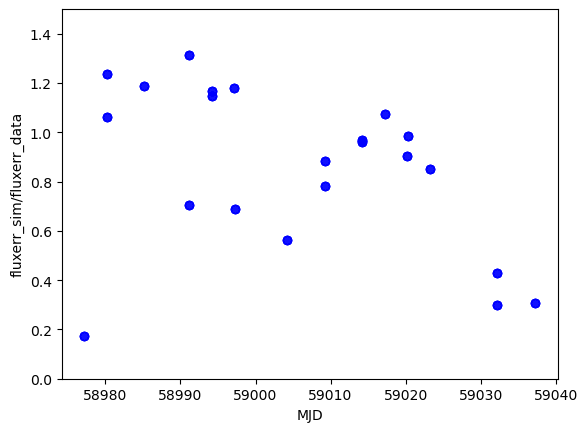

In [28]:
ztf_lc = lc_plot.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]

for i in range(0,len(lightcurves)):
    lynx_lc = lc_all.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[i]
    
    merged = pd.merge_asof(
        lynx_lc.sort_values('mjd'),
        ztf_lc.sort_values('mjd'),
        on='mjd',
        direction='nearest',
        tolerance=0.01,
        suffixes = ('_lynx','_ztf'),
    )
    merged = merged.dropna().loc[merged.dropna().detection_flag]
    plt.plot(merged.mjd,merged.fluxerr/merged.flux_err,'o',color='b',alpha=0.02)
plt.ylim((0,1.5))
plt.xlabel('MJD')
plt.ylabel("fluxerr_sim/fluxerr_data")

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1251: 

Text(0, 0.5, 'snr_sim/snr_data')

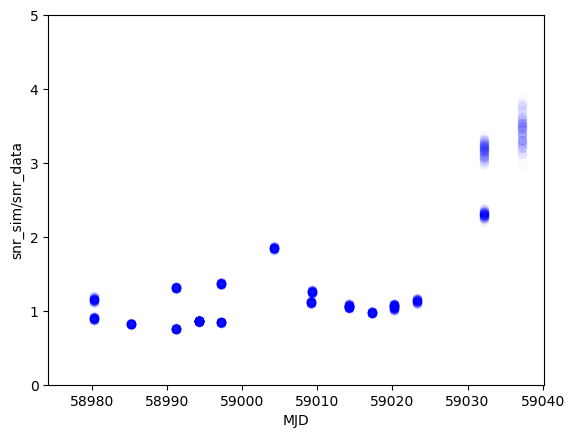

In [29]:
ztf_lc = lc_plot.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[0]

for i in range(0,len(lightcurves)):
    lynx_lc = lc_all.query(f"lc.mjd > {t_min} & lc.mjd < {t_max}")["lc"].iloc[i]
    
    merged = pd.merge_asof(
        lynx_lc.sort_values('mjd'),
        ztf_lc.sort_values('mjd'),
        on='mjd',
        direction='nearest',
        tolerance=0.01,
        suffixes = ('_lynx','_ztf'),
    )
    merged = merged.dropna().loc[merged.dropna().detection_flag]
    plt.plot(merged.mjd,(merged.flux_lynx/merged.fluxerr)/(merged.flux_ztf/merged.flux_err),'o',color='b',alpha=0.02)
plt.ylim((0,5))
plt.xlabel('MJD')
plt.ylabel("snr_sim/snr_data")

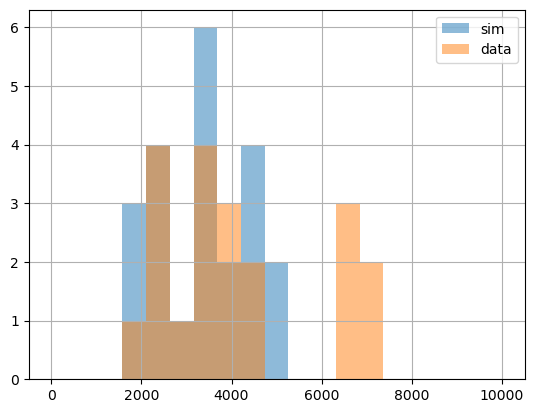

In [30]:
(merged.fluxerr).hist(bins=np.linspace(0,1e4,20),alpha=0.5,label='sim')
(merged.flux_err).hist(bins=np.linspace(0,1e4,20),alpha=0.5,label='data')
plt.legend()

In [31]:
merged.columns

Index(['mjd', 'filter_lynx', 'flux_lynx', 'fluxerr', 'flux_perfect',
       'survey_idx', 'is_saturated', 'expid', 'zp_nJy', 'scibckgnd',
       'skynoise', 'fwhm', 'maglimit', 'snr', 'detection_flag', 'filter_ztf',
       'flux_ztf', 'flux_err', 'ZP', 'flag', 'mag', 'mag_err', 'field_id',
       'rcid', 'flux_offset', 'offset_unc', 'err_scale', 'in_baseline',
       'pass_flag_filter'],
      dtype='object')

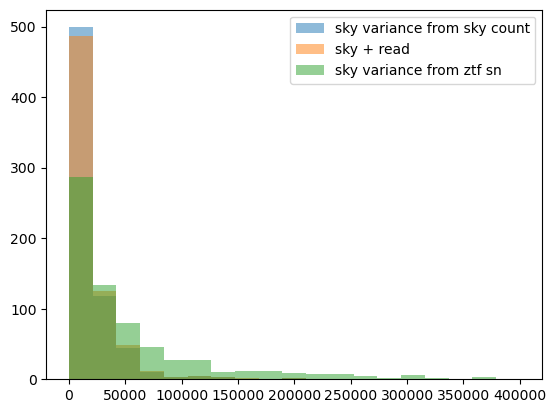

In [32]:
from lightcurvelynx.consts import GAUSS_EFF_AREA2FWHM_SQ
nea = GAUSS_EFF_AREA2FWHM_SQ * (obs_log["fwhm"]) ** 2
sky_variance = obs_log["scibckgnd"]*6.2*nea
readout_noise = 8.
sky_read_variance = sky_variance + readout_noise**2 * nea

# plt.plot(obs_log["scibckgnd"]*6.2*nea,obs_log["skynoise"]**2,'o',alpha=0.5)
# plt.ylim(plt.xlim()[:])
bins = np.linspace(0,4e5,20)
plt.hist(sky_variance,bins=bins,alpha=0.5,label='sky variance from sky count')
plt.hist(sky_read_variance, bins=bins, alpha=0.5, label='sky + read')
plt.hist((obs_log["skynoise"]*6.2)**2,bins=bins,alpha=0.5,label='sky variance from ztf sn') #skynoise = 1/5 * 10^(-0.4(maglim - magzp)) in ADU
plt.legend()

In [33]:
def ztfsn_noise_cal(skynoise, flux, zp):
    variance = (skynoise*gain)**2 + flux/zp  #skynoise is in ADU
    return np.sqrt(variance)*zp

In [34]:
ztf_noise = ztfsn_noise_cal(merged['skynoise'],merged['flux_perfect'],merged['zp_nJy'])

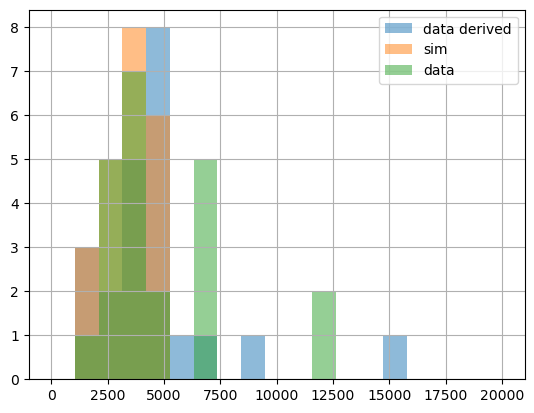

In [35]:
bins = np.linspace(0,2e4,20)
ztf_noise.hist(bins = bins,label="data derived",alpha=0.5)
merged["fluxerr"].hist(bins = bins,label="sim",alpha=0.5)
merged["flux_err"].hist(bins = bins,label="data",alpha=0.5)
plt.legend()

In [36]:
fp = pd.read_csv('/Users/mi/Downloads/2020jny_lc.txt',comment='#',sep=" ")

In [37]:
for c in fp.columns:
    fp = fp.rename(columns={c:c.split(',')[0]})

In [38]:
fp.columns

Index(['Unnamed: 0', 'index', 'field', 'ccdid', 'qid', 'filter', 'pid',
       'infobitssci', 'sciinpseeing', 'scibckgnd', 'scisigpix', 'zpmaginpsci',
       'zpmaginpsciunc', 'zpmaginpscirms', 'clrcoeff', 'clrcoeffunc',
       'ncalmatches', 'exptime', 'adpctdif1', 'adpctdif2', 'diffmaglim',
       'zpdiff', 'programid', 'jd', 'rfid', 'forcediffimflux',
       'forcediffimfluxunc', 'forcediffimsnr', 'forcediffimchisq',
       'forcediffimfluxap', 'forcediffimfluxuncap', 'forcediffimsnrap',
       'aperturecorr', 'dnearestrefsrc', 'nearestrefmag', 'nearestrefmagunc',
       'nearestrefchi', 'nearestrefsharp', 'refjdstart', 'refjdend',
       'procstatus'],
      dtype='object')

In [39]:
# rid = (ccdid - 1)*4 +qid
fp['rid'] = (fp['ccdid'] - 1)*4 + fp['qid']
fp['mjd'] = fp['jd'] - 2_400_000.5
fp['filter'] = [x[-1] for x in fp['filter']]

In [40]:
fp

,Unnamed: 0,index,field,ccdid,qid,filter,pid,infobitssci,sciinpseeing,scibckgnd,...,dnearestrefsrc,nearestrefmag,nearestrefmagunc,nearestrefchi,nearestrefsharp,refjdstart,refjdend,procstatus,rid,mjd
0,NaN,0,575,10,1,g,874193103715,0,1.8049,93.0235,...,0.953303,18.582,0.086,6.912,0.45,2.458167e+06,2.458431e+06,0,37,58628.193102
1,NaN,1,575,10,1,g,874194003715,0,1.7596,93.3396,...,0.953303,18.582,0.086,6.912,0.45,2.458167e+06,2.458431e+06,0,37,58628.194005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,NaN,497,575,10,1,g,1782531363715,0,1.9268,108.5660,...,0.953303,18.582,0.086,6.912,0.45,2.458167e+06,2.458431e+06,0,37,59536.531366
498,NaN,498,575,10,1,g,1796478373715,0,2.1542,102.8850,...,0.953303,18.582,0.086,6.912,0.45,2.458167e+06,2.458431e+06,0,37,59550.478380


In [41]:
lynx_lc = lightcurves['lc'].iloc[0]
ztf_lc = random_lc['lc'].iloc[0]
ztf_lc['filter'] = [x[-1] for x in ztf_lc['filter']]

In [42]:
lynx_lc

,mjd,filter,flux,fluxerr,flux_perfect,survey_idx,is_saturated,expid,zp_nJy,scibckgnd,skynoise,fwhm,maglimit,snr,detection_flag
0,58290.191406,g,1883.027901,1881.682983,0.0,0,False,53619111,20.932277,82.5505,38.285114,2.488525,20.411980,1.000715,False
1,58290.253906,r,-2738.394589,2655.564612,0.0,0,False,53625289,21.114797,219.2490,40.759636,2.214460,20.334553,-1.031191,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,59256.355469,r,221.092560,2963.832549,0.0,0,False,150235403,20.030468,417.3925,14.649752,1.908720,21.502792,0.074597,False
689,59269.292969,r,-842.402801,2635.684651,0.0,0,False,151529188,19.986567,414.6525,29.095768,1.706595,20.760176,-0.319614,False


In [43]:
ztf_lc

,mjd,filter,flux,flux_err,ZP,flag,mag,mag_err,field_id,rcid,flux_offset,offset_unc,err_scale,in_baseline,pass_flag_filter
0,58131.45685,g,938.89350,1248.08315,30.0,64,99.0,99.0,575,37.0,-171.27878,152.90124,1.00000,1,True
1,58131.46291,g,-701.20079,1136.62071,30.0,64,99.0,99.0,575,37.0,-171.27878,152.90124,1.00000,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,59798.16117,r,-8168.96201,3532.85301,30.0,392,99.0,99.0,575,37.0,-567.64475,174.40047,1.24398,0,False
842,59798.16354,r,8585.96939,3438.76922,30.0,392,99.0,99.0,575,37.0,-567.64475,174.40047,1.24398,0,False


In [44]:
ztf_lc["flux"], ztf_lc["flux_err"] = convert_flux_to_njy(ztf_lc["flux"],ztf_lc["flux_err"],zp=30.)
ztf_lc = ztf_lc.rename(columns={'flux_err':'fluxerr'})

In [45]:
merged = pd.merge_asof(
    ztf_lc.sort_values('mjd'),
    lynx_lc.sort_values('mjd'),
    on='mjd',
    by=['filter'],
    direction='nearest',
    tolerance=0.01,
    suffixes = ('_ztf','_lynx'),
)
merged = merged.dropna()

In [46]:
merged_all = pd.merge_asof(
    fp.sort_values('mjd'),
    merged.sort_values('mjd'),
    on='mjd',
    by=['filter'],
    direction='nearest',
    tolerance=0.001,
    suffixes = ('_fp','_merged'),
)

In [47]:
merged_all = merged_all[merged_all.columns[1:]]
merged_all = merged_all.dropna()

In [48]:
merged_all

,index,field,ccdid,qid,filter,pid,infobitssci,sciinpseeing,scibckgnd_fp,scisigpix,...,survey_idx,is_saturated,expid,zp_nJy,scibckgnd_merged,skynoise,fwhm,maglimit,snr,detection_flag
0,0,575,10,1,g,874193103715,0,1.8049,93.0235,4.97620,...,0.0,False,87419310.0,21.224431,79.85250,11.413801,1.892580,21.710930,-0.431428,False
1,1,575,10,1,g,874194003715,0,1.7596,93.3396,5.11011,...,0.0,False,87419400.0,21.388147,79.89935,10.428707,1.864775,21.800587,0.997824,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,575,10,1,g,1514489403715,0,1.8618,112.7020,6.64677,...,0.0,False,151448940.0,17.732992,97.25800,17.069878,1.968465,21.469065,0.145178,False
396,396,575,10,1,r,1516340133715,0,2.0717,250.6770,13.74020,...,0.0,False,151634013.0,17.974304,258.90850,45.397270,2.026150,20.392391,-1.672064,False


In [49]:
merged_all.columns

Index(['index', 'field', 'ccdid', 'qid', 'filter', 'pid', 'infobitssci',
       'sciinpseeing', 'scibckgnd_fp', 'scisigpix', 'zpmaginpsci',
       'zpmaginpsciunc', 'zpmaginpscirms', 'clrcoeff', 'clrcoeffunc',
       'ncalmatches', 'exptime', 'adpctdif1', 'adpctdif2', 'diffmaglim',
       'zpdiff', 'programid', 'jd', 'rfid', 'forcediffimflux',
       'forcediffimfluxunc', 'forcediffimsnr', 'forcediffimchisq',
       'forcediffimfluxap', 'forcediffimfluxuncap', 'forcediffimsnrap',
       'aperturecorr', 'dnearestrefsrc', 'nearestrefmag', 'nearestrefmagunc',
       'nearestrefchi', 'nearestrefsharp', 'refjdstart', 'refjdend',
       'procstatus', 'rid', 'mjd', 'flux_ztf', 'fluxerr_ztf', 'ZP', 'flag',
       'mag', 'mag_err', 'field_id', 'rcid', 'flux_offset', 'offset_unc',
       'err_scale', 'in_baseline', 'pass_flag_filter', 'flux_lynx',
       'fluxerr_lynx', 'flux_perfect', 'survey_idx', 'is_saturated', 'expid',
       'zp_nJy', 'scibckgnd_merged', 'skynoise', 'fwhm', 'maglimit', 'sn

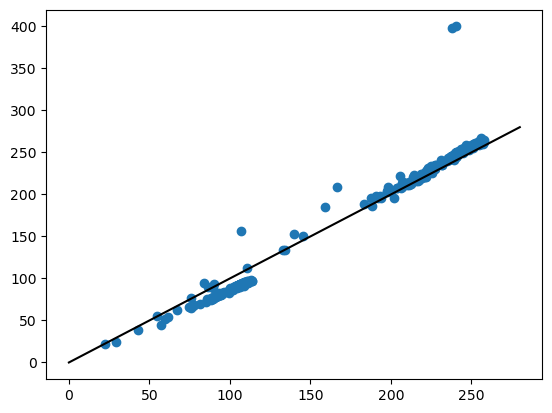

In [50]:
plt.scatter(merged_all['scibckgnd_fp'],merged_all['scibckgnd_merged'])
plt.plot([0,280],[0,280],color='k')

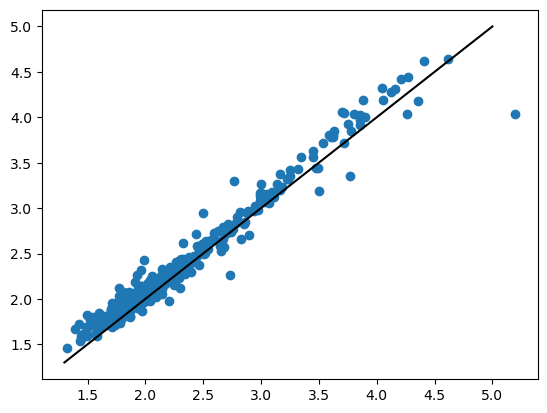

In [51]:
plt.scatter(merged_all['sciinpseeing'],merged_all['fwhm'])
plt.plot([1.3,5],[1.3,5],color='k')

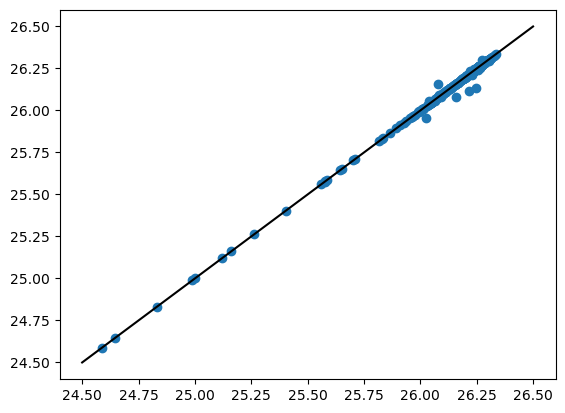

In [52]:
gain=6.2
plt.scatter(merged_all['zpmaginpsci'],flux2mag(merged_all['zp_nJy'])-2.5*np.log10(gain))
plt.plot([24.5,26.5],[24.5,26.5],color='k')

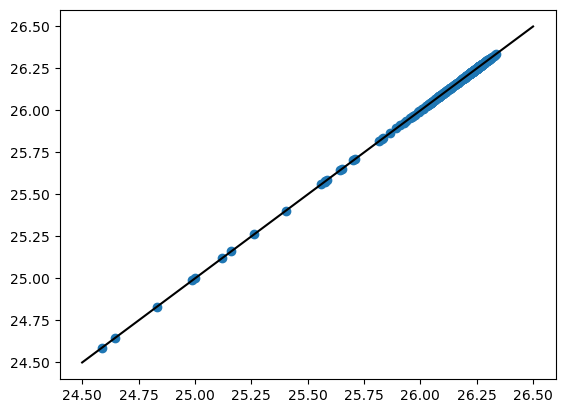

In [53]:
plt.scatter(merged_all['zpmaginpsci'],merged_all['zpdiff'])
plt.plot([24.5,26.5],[24.5,26.5],color='k')

In [54]:
merged_all.columns

Index(['index', 'field', 'ccdid', 'qid', 'filter', 'pid', 'infobitssci',
       'sciinpseeing', 'scibckgnd_fp', 'scisigpix', 'zpmaginpsci',
       'zpmaginpsciunc', 'zpmaginpscirms', 'clrcoeff', 'clrcoeffunc',
       'ncalmatches', 'exptime', 'adpctdif1', 'adpctdif2', 'diffmaglim',
       'zpdiff', 'programid', 'jd', 'rfid', 'forcediffimflux',
       'forcediffimfluxunc', 'forcediffimsnr', 'forcediffimchisq',
       'forcediffimfluxap', 'forcediffimfluxuncap', 'forcediffimsnrap',
       'aperturecorr', 'dnearestrefsrc', 'nearestrefmag', 'nearestrefmagunc',
       'nearestrefchi', 'nearestrefsharp', 'refjdstart', 'refjdend',
       'procstatus', 'rid', 'mjd', 'flux_ztf', 'fluxerr_ztf', 'ZP', 'flag',
       'mag', 'mag_err', 'field_id', 'rcid', 'flux_offset', 'offset_unc',
       'err_scale', 'in_baseline', 'pass_flag_filter', 'flux_lynx',
       'fluxerr_lynx', 'flux_perfect', 'survey_idx', 'is_saturated', 'expid',
       'zp_nJy', 'scibckgnd_merged', 'skynoise', 'fwhm', 'maglimit', 'sn

In [55]:
flux_fp = merged_all['forcediffimflux']*gain*merged_all['zp_nJy']
fluxerr_fp = merged_all['forcediffimfluxunc']*gain*merged_all['zp_nJy']

<ErrorbarContainer object of 3 artists>

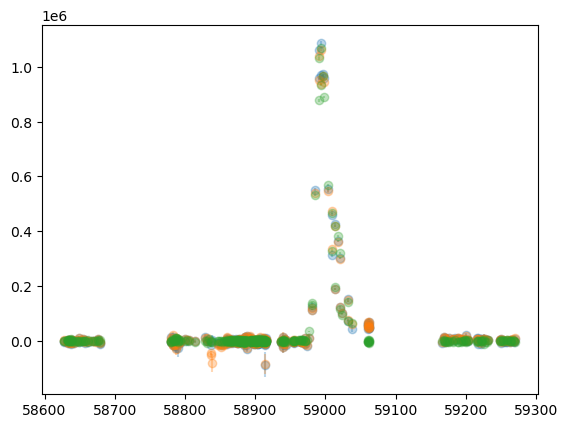

In [56]:
plt.errorbar(merged_all['mjd'],flux_fp, yerr=fluxerr_fp, fmt='o',alpha=0.3)
plt.errorbar(merged_all['mjd'],merged_all['flux_ztf'],yerr=merged_all['fluxerr_ztf'],fmt='o',alpha=0.3)
plt.errorbar(merged_all['mjd'],merged_all['flux_lynx'],yerr=merged_all['fluxerr_lynx'],fmt='o',alpha=0.3)

<Axes: >

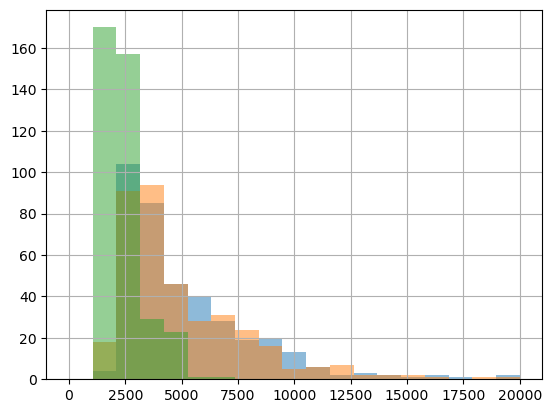

In [57]:
bins = np.linspace(0,20000,20)
fluxerr_fp.hist(bins=bins,alpha=0.5)
merged_all['fluxerr_ztf'].hist(bins=bins,alpha=0.5)
merged_all['fluxerr_lynx'].hist(bins=bins,alpha=0.5)

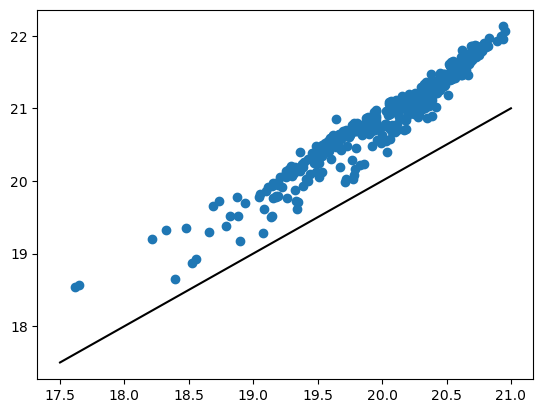

In [59]:
plt.scatter(merged_all['diffmaglim'],merged_all['maglimit'])
plt.plot([17.5,21],[17.5,21],color='k')

In [64]:
merged_all.columns

Index(['index', 'field', 'ccdid', 'qid', 'filter', 'pid', 'infobitssci',
       'sciinpseeing', 'scibckgnd_fp', 'scisigpix', 'zpmaginpsci',
       'zpmaginpsciunc', 'zpmaginpscirms', 'clrcoeff', 'clrcoeffunc',
       'ncalmatches', 'exptime', 'adpctdif1', 'adpctdif2', 'diffmaglim',
       'zpdiff', 'programid', 'jd', 'rfid', 'forcediffimflux',
       'forcediffimfluxunc', 'forcediffimsnr', 'forcediffimchisq',
       'forcediffimfluxap', 'forcediffimfluxuncap', 'forcediffimsnrap',
       'aperturecorr', 'dnearestrefsrc', 'nearestrefmag', 'nearestrefmagunc',
       'nearestrefchi', 'nearestrefsharp', 'refjdstart', 'refjdend',
       'procstatus', 'rid', 'mjd', 'flux_ztf', 'fluxerr_ztf', 'ZP', 'flag',
       'mag', 'mag_err', 'field_id', 'rcid', 'flux_offset', 'offset_unc',
       'err_scale', 'in_baseline', 'pass_flag_filter', 'flux_lynx',
       'fluxerr_lynx', 'flux_perfect', 'survey_idx', 'is_saturated', 'expid',
       'zp_nJy', 'scibckgnd_merged', 'skynoise', 'fwhm', 'maglimit', 'sn

In [71]:
from lightcurvelynx.consts import GAUSS_EFF_AREA2FWHM_SQ
nea = GAUSS_EFF_AREA2FWHM_SQ * (merged_all["sciinpseeing"]) ** 2
err = poisson_bandflux_std(merged_all['flux_perfect'],    
                     total_exposure_time = merged_all['exptime'],
                     exposure_count=1,
                     psf_footprint=nea,
                     sky=merged_all['scibckgnd_fp']*gain,
                     zp=merged_all['zp_nJy'],
                     readout_noise=8.,
                     dark_current=0.,
                     zp_err_mag=0.,)

<Axes: >

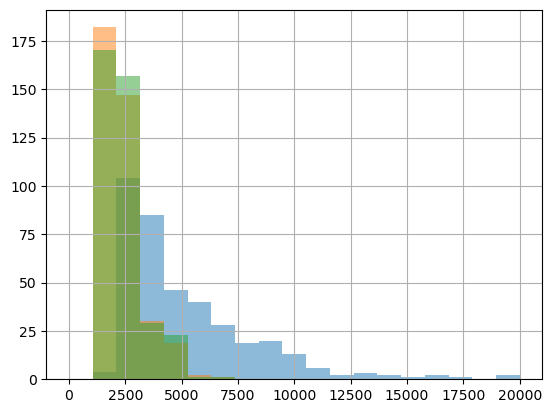

In [72]:
bins = np.linspace(0,20000,20)
fluxerr_fp.hist(bins=bins,alpha=0.5)
err.hist(bins=bins,alpha=0.5)
merged_all['fluxerr_lynx'].hist(bins=bins,alpha=0.5)

<Axes: >

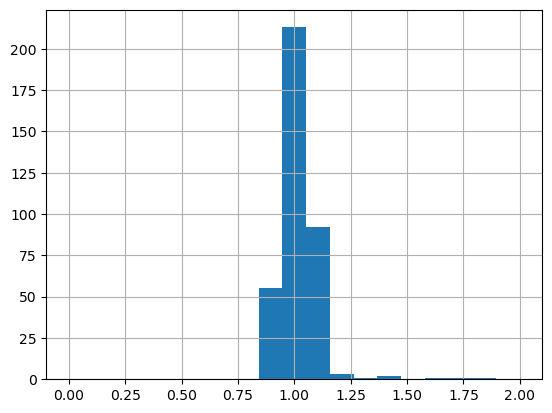

In [76]:
merged_all['forcediffimchisq'].hist(bins=np.linspace(0,2,20))